In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('..'))
from notebook_utils import setup_env, load_data_for_modeling

PROJECT_ROOT, config = setup_env()
MODELS_DIR = PROJECT_ROOT / config['paths']['models']

In [2]:
# 2. Загрузка данных
df = load_data_for_modeling(config, PROJECT_ROOT, fill_cats=True)
target_col = config['features']['target_col']
cat_cols = config['features']['cat_cols']

Загрузка данных из: D:\Education\Arcticle\dtp_project\data\processed\dtp_full_dataset.parquet
Режим таргета: binary_severe. Распределение:
target
0    0.6065
1    0.3935
Name: proportion, dtype: float64


In [3]:
# 3. Загрузка Модели
print("Loading Model...")
model = CatBoostClassifier()
model_path = MODELS_DIR / f"catboost_{config['experiment']['target_mode']}.cbm"
model.load_model(str(model_path))

Loading Model...


In [4]:
# 4. Подготовка данных для SHAP
# SHAP считается долго. Для графика достаточно взять подвыборку (5000-10000 строк).
# Берем из Test выборки, чтобы быть честными
X = df.drop(columns=[target_col])
y = df[target_col]
_, X_shap, _, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Если тест слишком большой, берем сэмпл
if len(X_shap) > 5000:
    X_shap = X_shap.sample(5000, random_state=42)

print(f"Calculating SHAP for {len(X_shap)} samples...")

# Создаем Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(Pool(X_shap, cat_features=cat_cols))

# shap_values - это массив (N_samples, N_features)
# Нам нужно превратить его в DataFrame для удобства
df_shap = pd.DataFrame(shap_values, columns=X.columns)

Calculating SHAP for 5000 samples...


In [5]:
# 5. Группировка
feature_groups = {
    'GEO (География)': {
        'lat', 'long', 'region_id', 'geo_cluster'
    },
    'TIME (Время)': {
        'year', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'is_weekend'
    },
    'LIGHT (Освещение)': {
        'light_cat'
    },
    'NEARBY (Инфраструктура)': {
        'near_residential', 'near_pedestrian_infrastructure', 'near_road_junctions', 
        'near_education', 'near_commercial', 'near_public_transport', 'near_railway', 
        'near_transport_hubs', 'near_administrative', 'near_healthcare', 
        'near_road_objects', 'near_other', 'nearby_objects_count'
    },
    'WEATHER (Погода)': {
        'weather_clear', 'weather_fog', 'weather_hot', 'weather_overcast', 
        'weather_rain', 'weather_snow', 'weather_wind', 'weather_other'
    },
    'ROAD (Дорога)': {
        'road_bad_fences', 'road_bad_infrastructure', 'road_bad_lights', 
        'road_bad_maintenance', 'road_bad_markings', 'road_bad_signs', 
        'road_bad_surface', 'road_dirty', 'road_dry', 'road_ice', 
        'road_no_light', 'road_obstacles', 'road_roadworks', 
        'road_snow', 'road_wet', 'road_other'
    },
    'VEHICLES (ТС)': {
        'vh_count', 'vh_is_solo', 'vh_is_mass', 'vh_heavy_light_conflict', 
        'vh_age_gap', 'vh_max_age', 'vh_mean_age', 'vh_count_car', 
        'vh_count_truck', 'vh_count_bus', 'vh_count_moto', 'vh_count_special', 
        'vh_count_brand_ru', 'vh_count_brand_premium', 'vh_count_brand_chinese', 
        'vh_count_brand_mass', 'vh_count_brand_commercial', 'vh_count_color_dark', 
        'vh_count_color_light', 'vh_count_color_colored'
    },
    'PEOPLE (Участники)': {
        'ppl_count', 'ppl_pass_count', 'ppl_ped_count', 'ppl_solo_count', 
        'ppl_ped_worker_count', 'ppl_ped_other_count', 'ppl_drv_male', 
        'ppl_drv_female', 'ppl_drv_exp_min', 'ppl_drv_exp_mean', 'ppl_drv_novice'
    },
    'VIOLATIONS (Нарушения)': {
        'viol_priority', 'viol_pedestrian', 'viol_speed', 'viol_drunk', 
        'viol_safety', 'viol_rights', 'viol_runaway', 'viol_admin'
    },
    'OTHER (Категория/Схема)': {
        'scheme', 'category'
    }
}

# Считаем средний абсолютный SHAP для каждой группы
# Logic: sum(|SHAP|) по фичам группы для каждого семпла -> mean по всем семплам
group_shap_importance = {}

# Создаем обратный маппинг feature -> group
feat_to_group = {}
for grp, feats in feature_groups.items():
    for f in feats:
        feat_to_group[f] = grp

# Проходимся по колонкам df_shap
for col in df_shap.columns:
    # Определяем группу
    group = feat_to_group.get(col)
    
    # Если не нашли в списке, проверяем engineered features
    if group is None:
        if col.startswith('inter_'):
            group = 'ENGINEERED (Синтетические)'
        else:
            group = 'OTHER (Категория/Схема)' # Или создать 'Unmapped'
    
    # Суммируем абсолютные значения
    # Мы добавляем вклад этой колонки в общую копилку группы
    # Вклад = среднее абсолютное значение (mean absolute impact)
    mean_abs_impact = df_shap[col].abs().mean()
    
    group_shap_importance[group] = group_shap_importance.get(group, 0) + mean_abs_impact

,Group,Mean |SHAP|,Share %
4,GEO (География),0.499476,18.417030
7,VEHICLES (ТС),0.484537,17.866203
8,PEOPLE (Участники),0.475997,17.551299
9,VIOLATIONS (Нарушения),0.324842,11.977793
1,OTHER (Категория/Схема),0.266562,9.828862
3,NEARBY (Инфраструктура),0.237499,8.757231
6,ROAD (Дорога),0.184776,6.813199
2,TIME (Время),0.133859,4.935735
0,LIGHT (Освещение),0.062815,2.316144
5,WEATHER (Погода),0.041670,1.536503


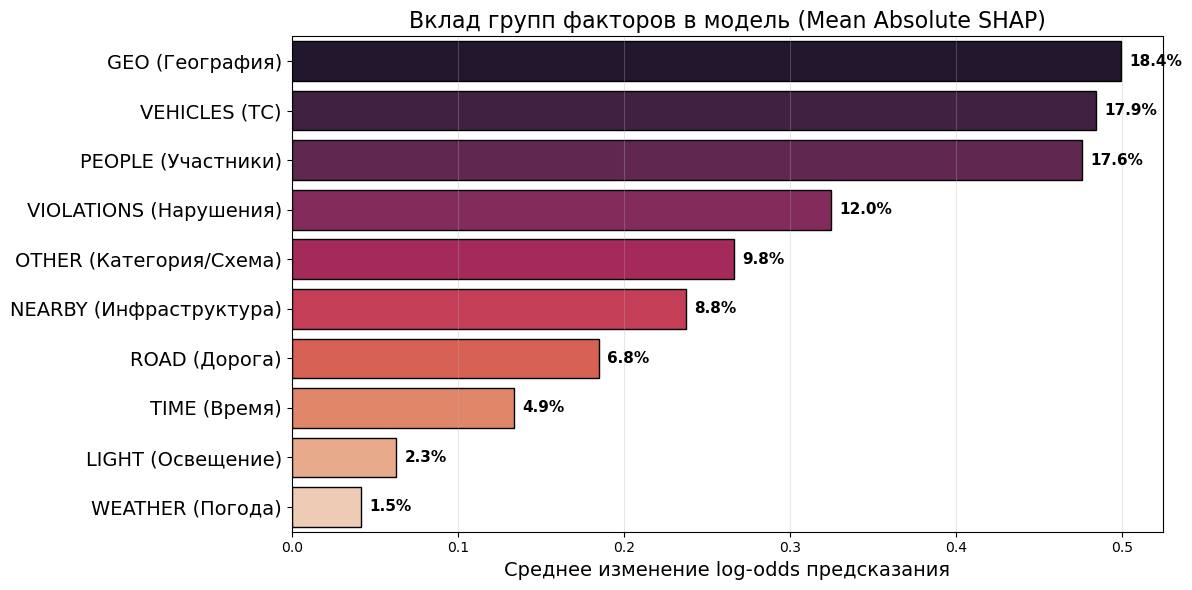

In [9]:
# 6. Визуализация
df_res = pd.DataFrame(list(group_shap_importance.items()), columns=['Group', 'Mean |SHAP|'])
df_res = df_res.sort_values(by='Mean |SHAP|', ascending=False)
df_res['Share %'] = (df_res['Mean |SHAP|'] / df_res['Mean |SHAP|'].sum()) * 100

display(df_res)

# Plot
plt.figure(figsize=(12, 6))  # ← чуть выше, чтобы текст не обрезался
barplot = sns.barplot(
    data=df_res, 
    y='Group', 
    x='Mean |SHAP|', 
    palette='rocket',
    edgecolor='black',
    hue='Group',          # ← привязываем палитру к y-переменной
    legend=False            # ← скрываем дублирующую легенду
)

plt.yticks(fontsize=14)

max_val = df_res['Mean |SHAP|'].max()
for i, p in enumerate(barplot.patches):
    width = p.get_width()
    percentage = df_res.iloc[i]['Share %']
    plt.text(
        width + (max_val * 0.01),
        p.get_y() + p.get_height()/2,
        f'{percentage:.1f}%',
        ha='left', va='center', fontsize=11, fontweight='bold'
    )

plt.title('Вклад групп факторов в модель (Mean Absolute SHAP)', fontsize=16)
plt.xlabel('Среднее изменение log-odds предсказания', fontsize=14)
plt.ylabel(None)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

# Сохранение
plt.savefig(PROJECT_ROOT / 'data/processed/group_shap_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
print(df_res)

                     Group  Mean |SHAP|    Share %
4          GEO (География)     0.499476  18.417030
7            VEHICLES (ТС)     0.484537  17.866203
8       PEOPLE (Участники)     0.475997  17.551299
9   VIOLATIONS (Нарушения)     0.324842  11.977793
1  OTHER (Категория/Схема)     0.266562   9.828862
3  NEARBY (Инфраструктура)     0.237499   8.757231
6            ROAD (Дорога)     0.184776   6.813199
2             TIME (Время)     0.133859   4.935735
0        LIGHT (Освещение)     0.062815   2.316144
5         WEATHER (Погода)     0.041670   1.536503
